#Name: **Sk Md Saad Bin Sohan**



#Student ID: **221___id**

#1a) Plotting the piece-wise function for water flow

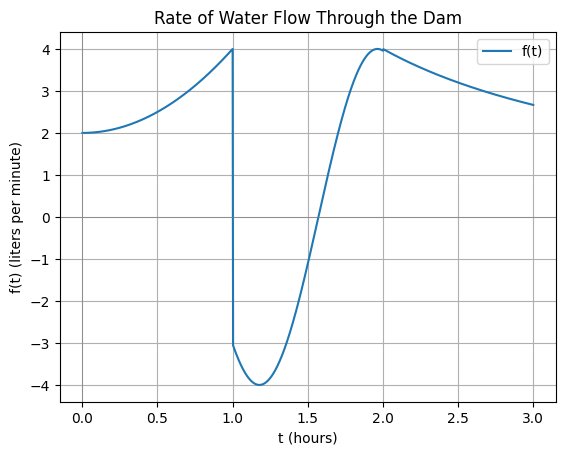

In [1]:
#id = "221___id"

import numpy as np
import matplotlib.pyplot as plt

a = 2
b = 2
c = a + b
d = 4
e = a * d
f_digit = 2

#piecewise function
def f(t):
    if 0 <= t <= 1:
        return a * t**2 + b
    elif 1 < t <= 2:
        return c * np.sin(d * t)
    elif 2 < t <= 3:
        return e / (t - 2 + f_digit)

# Generating values for t
t_values = np.linspace(0, 3, 1000)
f_values = [f(t) for t in t_values]

# Plotting
plt.plot(t_values, f_values, label="f(t)")
plt.axhline(0, color='gray', lw=0.5)  # f(t) = 0
plt.axvline(0, color='gray', lw=0.5)  # t = 0
plt.xlabel('t (hours)')
plt.ylabel('f(t) (liters per minute)')
plt.title('Rate of Water Flow Through the Dam')
plt.legend()
plt.grid(True)
plt.show()


#1b) Estimating total volume using Monte Carlo Method

In [2]:
import random

def monte_carlo_integral(f, t_min, t_max, n_points):
    t_values = np.linspace(t_min, t_max, n_points)
    f_values = [f(t) for t in t_values]

    max_f = max(f_values)
    count_under_curve = 0

    for _ in range(n_points):
        t_random = random.uniform(t_min, t_max)
        f_random = random.uniform(0, max_f)
        if f_random <= f(t_random):
            count_under_curve += 1

    return (count_under_curve / n_points) * (t_max - t_min) * max_f

total_volume = monte_carlo_integral(f, 0, 3, 10000)
print("Estimated total volume of water flowing through the dam: ", total_volume, " liters")

Estimated total volume of water flowing through the dam:  7.1124  liters


#1c) Finding local maximum of the rate of water flow

In [3]:
from scipy.optimize import minimize_scalar

# Derivatives of each piece of the piecewise function
def df_dt_0_to_1(t):
    return 2 * a * t

def df_dt_1_to_2(t):
    return c * d * np.cos(d * t)

def df_dt_2_to_3(t):
    return -e / (t - 2 + f)**2

# Finding the local maxima
max_f_0_to_1 = minimize_scalar(lambda t: -f(t), bounds=(0, 1), method='bounded')
max_f_1_to_2 = minimize_scalar(lambda t: -f(t), bounds=(1, 2), method='bounded')
max_f_2_to_3 = minimize_scalar(lambda t: -f(t), bounds=(2, 3), method='bounded')

print("Local maximum in [0,1]: f(t) =", f(max_f_0_to_1.x), "at t =", max_f_0_to_1.x)
print("Local maximum in [1,2]: f(t) =", f(max_f_1_to_2.x), "at t =", max_f_1_to_2.x)
print("Local maximum in [2,3]: f(t) =", f(max_f_2_to_3.x), "at t =", max_f_2_to_3.x)

Local maximum in [0,1]: f(t) = 3.9999761566271177 at t = 0.9999940391390134
Local maximum in [1,2]: f(t) = 3.9999999999999725 at t = 1.9634953791618432
Local maximum in [2,3]: f(t) = 3.9999880783135593 at t = 2.000005960860986


#1d) Comparing local maxima with average rate of flow

In [4]:
#rate of flow = volume / Time

time_interval = 3  # from 0 to 3 hours
average_flow_rate = total_volume / time_interval

print("Average rate of water flow over the interval [0, 3]:", average_flow_rate, "liters per minute")

# Comparing with local maxima
print("Comparison with local maxima:")
print("Local maximum in [0,1]:", f(max_f_0_to_1.x))
print("Local maximum in [1,2]:", f(max_f_1_to_2.x))
print("Local maximum in [2,3]:", f(max_f_2_to_3.x))

Average rate of water flow over the interval [0, 3]: 2.3708 liters per minute
Comparison with local maxima:
Local maximum in [0,1]: 3.9999761566271177
Local maximum in [1,2]: 3.9999999999999725
Local maximum in [2,3]: 3.9999880783135593


#2a) Implementing Simpson’s 1/3 Rule to evaluate the integral for multiple values of N

In [5]:
import numpy as np

# piecewise function
def f(x):
    return np.where(
        (x >= 0) & (x < 1), np.sin(x),  # using x < 1 to avoid x = 1 and zero divide situation
        np.where((x > 1) & (x <= 2), 1/np.where(x == 0, np.inf, x),  # Handling x = 0 division
                 np.where((x > 2) & (x <= 3), x**3, 0)))

# Simpson's rule
def simpsons_rule(f, a, b, N):
    if N % 2 == 1:
        N += 1
    h = (b - a) / N
    x = np.linspace(a, b, N+1)
    y = f(x)

    result = y[0] + y[-1] + 4 * sum(y[1:-1:2]) + 2 * sum(y[2:-1:2])
    result *= h / 3

    return result

# Calculating the integral
N_values = [10, 100, 1000, 10000]
simpsons_results = [simpsons_rule(f, 0, 3, N) for N in N_values]

# Print results
for N, result in zip(N_values, simpsons_results):
    print(f"Simpson's rule result for N = {N}: {result}")


Simpson's rule result for N = 10: 18.131311785638978
Simpson's rule result for N = 100: 17.47625367784022
Simpson's rule result for N = 1000: 17.41018633974093
Simpson's rule result for N = 10000: 17.403579021784342


#2b) Implementing the Trapezoidal rule for the same values of N

In [6]:
def trapezoidal_rule(f, a, b, N):
    h = (b - a) / N
    x = np.linspace(a, b, N+1)
    y = f(x)

    result = (y[0] + y[-1]) / 2 + sum(y[1:-1])
    result *= h

    return result

# Integral values using the trapezoidal rule
trapezoidal_results = [trapezoidal_rule(f, 0, 3, N) for N in N_values]

for N, result in zip(N_values, trapezoidal_results):
    print(f"Trapezoidal rule result for N = {N}: {result}")

Trapezoidal rule result for N = 10: 17.99011354357182
Trapezoidal rule result for N = 100: 17.441768478831577
Trapezoidal rule result for N = 1000: 17.40653778612304
Trapezoidal rule result for N = 10000: 17.403212170013806


#2c) Plotting results from part a and b to compare accuracy

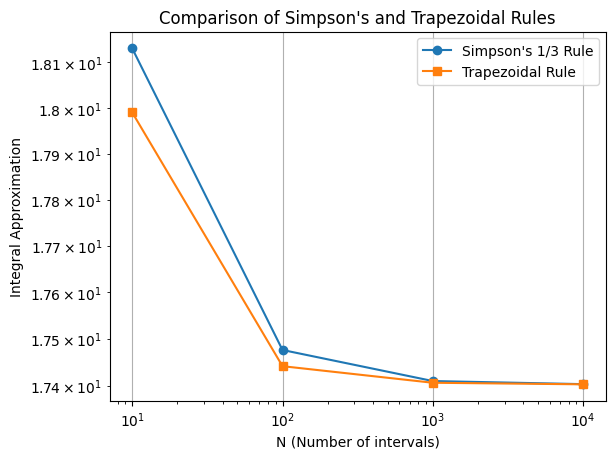

In [7]:
import matplotlib.pyplot as plt

# Plotting the results vs N for both Simpson's and Trapezoidal rules
plt.plot(N_values, simpsons_results, label="Simpson's 1/3 Rule", marker='o')
plt.plot(N_values, trapezoidal_results, label="Trapezoidal Rule", marker='s')

# Log scaling for visibility of the convergence
plt.xscale('log')
plt.yscale('log')

plt.xlabel('N (Number of intervals)')
plt.ylabel('Integral Approximation')
plt.title('Comparison of Simpson\'s and Trapezoidal Rules')
plt.legend()
plt.grid(True)
plt.show()

#3a) Numerical Integration for Fresnel Integral using Trapezoidal Rule or Monte Carlo

/var/folders/fn/n7h4yl_173jdy0t3rw3lwtmc0000gn/T/ipykernel_9984/3727851156.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(np.cos(alpha * x**2 + beta), x)
/var/folders/fn/n7h4yl_173jdy0t3rw3lwtmc0000gn/T/ipykernel_9984/3727851156.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(np.sin(alpha * x**2 + beta), x)


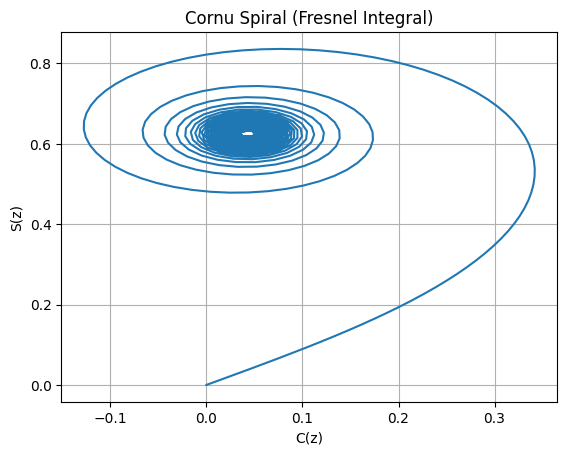

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# id = '24121125'
alpha = 2
beta = 7

# Fresnel integrals
def C(z):
    x = np.linspace(0, z, 1000)
    return np.trapz(np.cos(alpha * x**2 + beta), x)

def S(z):
    x = np.linspace(0, z, 1000)
    return np.trapz(np.sin(alpha * x**2 + beta), x)

# Calculating C(z) and S(z) for  z values
z_values = np.linspace(0, 20, 1000)
C_values = [C(z) for z in z_values]
S_values = [S(z) for z in z_values]

#plotting
plt.plot(C_values, S_values)
plt.title("Cornu Spiral (Fresnel Integral)")
plt.xlabel("C(z)")
plt.ylabel("S(z)")
plt.grid(True)
plt.show()

#3b) Visualizing Cornu Spirals for Three Different Student IDs

/var/folders/fn/n7h4yl_173jdy0t3rw3lwtmc0000gn/T/ipykernel_9984/2277006243.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  C_values = [np.trapz(np.cos(alpha * np.linspace(0, z, 1000)**2 + beta), x=np.linspace(0, z, 1000)) for z in z_values]
/var/folders/fn/n7h4yl_173jdy0t3rw3lwtmc0000gn/T/ipykernel_9984/2277006243.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  S_values = [np.trapz(np.sin(alpha * np.linspace(0, z, 1000)**2 + beta), x=np.linspace(0, z, 1000)) for z in z_values]


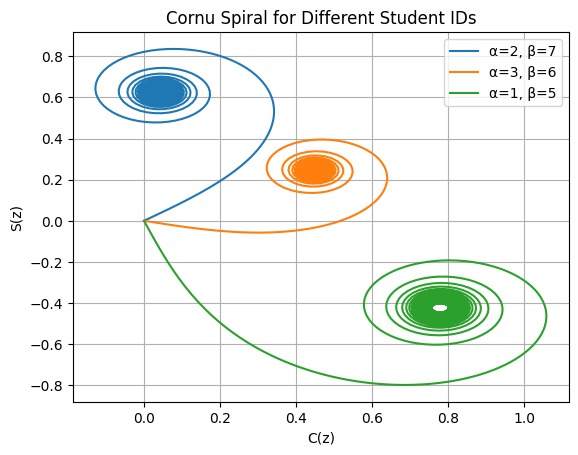

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# calculating C(z) and S(z) for different alpha, beta values
def fresnel_integrals(alpha, beta):
    z_values = np.linspace(0, 20, 1000)
    C_values = [np.trapz(np.cos(alpha * np.linspace(0, z, 1000)**2 + beta), x=np.linspace(0, z, 1000)) for z in z_values]
    S_values = [np.trapz(np.sin(alpha * np.linspace(0, z, 1000)**2 + beta), x=np.linspace(0, z, 1000)) for z in z_values]
    return C_values, S_values


alpha_beta_sets = [(2, 7), (3, 6), (1, 5)] # Different sets of alpha and beta based on different student IDs

# Plotting for different alpha, beta values
for alpha, beta in alpha_beta_sets:
    C_values, S_values = fresnel_integrals(alpha, beta)
    plt.plot(C_values, S_values, label=f'α={alpha}, β={beta}')

plt.title("Cornu Spiral for Different Student IDs")
plt.xlabel("C(z)")
plt.ylabel("S(z)")
plt.legend()
plt.grid(True)
plt.show()
